# Applied Statistics & Data Science I
## Discrete and Continuous Random Variables using Official CDC/NCHS NHANES Data

This notebook uses **NHANES 2017–2018 public-use data from the
U.S. Centers for Disease Control and Prevention (CDC), National Center for Health Statistics (NCHS)**.

To keep the focus on random variables, students load a single prepared CSV
(`nhanes_2017_2018_teaching.csv`). That file was built once from two official CDC files:

- `DEMO_J.xpt`: Demographic Variables and Sample Weights
  `https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/DEMO_J.xpt`
- `BMX_J.xpt`: Body Measures
  `https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/BMX_J.xpt`

The preparation steps (download, merge on `SEQN`, restrict to adults, keep complete cases)
are documented in `Prepare_NHANES_CDC_CSV_instructor.ipynb`.

Official documentation:

- NHANES 2017–2018:
  `https://wwwn.cdc.gov/nchs/nhanes/continuousnhanes/default.aspx?BeginYear=2017`
- Demographics codebook:
  `https://wwwn.cdc.gov/nchs/data/nhanes/public/2017/datafiles/DEMO_J.htm`
- Body Measures codebook:
  `https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/BMX_J.htm`

### Important statistical note

NHANES uses a **complex probability sampling design**. For nationally representative
population estimates, CDC recommends using survey weights, strata, and PSU information.

Here we intentionally use the observed public-use records **unweighted** only to illustrate
basic concepts about random variables, empirical distributions, sample means, and sampling
variability. We will return to sampling design and weighting later in the course.


## Learning goals

We will use one real dataset to distinguish:

$$
\text{random experiment}
\longrightarrow
\omega
\longrightarrow
X(\omega)
\longrightarrow
\text{distribution}.
$$

In particular, we will see:

1. a **discrete count random variable**: household size;
2. a **Bernoulli random variable** obtained from an indicator;
3. **continuous random variables**: height and BMI;
4. empirical probability distributions;
5. the connection between an indicator average and a sample proportion;
6. the $1/\sqrt{N}$ scaling of sampling fluctuations.


In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(413)

# NHANES 2017-2018 teaching extract: one row per adult participant, complete cases.
adults = pd.read_csv("nhanes_2017_2018_teaching.csv")

adults = adults.rename(columns={"household_size": "household_size_code"})

print("Adult teaching sample:", adults.shape)
adults.head()

Adult teaching sample: (5434, 5)


,age_years,household_size_code,height_cm,weight_kg,bmi
0,66,1,158.3,79.5,31.7
1,18,5,175.7,66.3,21.5
2,66,2,150.2,53.5,23.7
3,75,1,151.1,88.8,38.9
4,56,3,170.6,62.1,21.3


## 1. The teaching dataset

NHANES public-use data is released by CDC in SAS transport (`.xpt`) format and split
across several files (demographics, body measures, ...). For this lecture we skip the
download-and-merge step and read a single prepared file,
`nhanes_2017_2018_teaching.csv`.

It has one row per **adult** participant (age >= 18) with complete records for the
variables we need:

| column | meaning |
|:-|:-|
| `age_years` | age in years |
| `household_size_code` | people in the household; CDC top-codes `7` as "7 or more" |
| `height_cm` | standing height (cm) |
| `weight_kg` | weight (kg) |
| `bmi` | body mass index (kg/m$^2$), released to one decimal |

The CSV was built once from the official files `DEMO_J` and `BMX_J`; the exact steps are
in `Prepare_NHANES_CDC_CSV_instructor.ipynb`.


# Part I - One sample space, many random variables

Imagine the experiment:

> **Select one participant record from the observed adult NHANES sample.**

An outcome $\omega$ is the complete record of the selected participant.

We may define several different random variables on the same sample space:

$$
X(\omega)=\text{household-size code of participant }\omega,
$$

$$
Y(\omega)=\text{height of participant }\omega,
$$

$$
Z(\omega)=\text{BMI of participant }\omega.
$$

The random variable is a **function of the outcome**. The same outcome can therefore
generate many different numerical random variables.


In [20]:
adults[["household_size_code", "height_cm", "bmi"]].head(100)

,household_size_code,height_cm,bmi
0,1,158.3,31.7
1,5,175.7,21.5
2,2,150.2,23.7
3,1,151.1,38.9
4,3,170.6,21.3
...,...,...,...
95,5,155.6,27.0
96,2,149.1,31.2
97,2,171.0,27.2
98,7,165.4,26.0



# Part II - A discrete random variable

## 2. Household size

The released variable `DMDHHSIZ` takes the values

$
1,2,3,4,5,6,7,
$

where the CDC codebook defines \(7\) to mean **7 or more**.

Thus the released variable is discrete.


In [4]:
hh = adults["household_size_code"].astype(int)

counts = hh.value_counts().sort_index()
probs = counts / counts.sum()

pmf = pd.DataFrame({
    "household_size_code": counts.index,
    "count": counts.values,
    "empirical_probability": probs.values,
})

pmf

,household_size_code,count,empirical_probability
0,1,731,0.134523
1,2,1650,0.303644
2,3,1006,0.185131
3,4,858,0.157895
4,5,613,0.112808
5,6,322,0.059257
6,7,254,0.046743


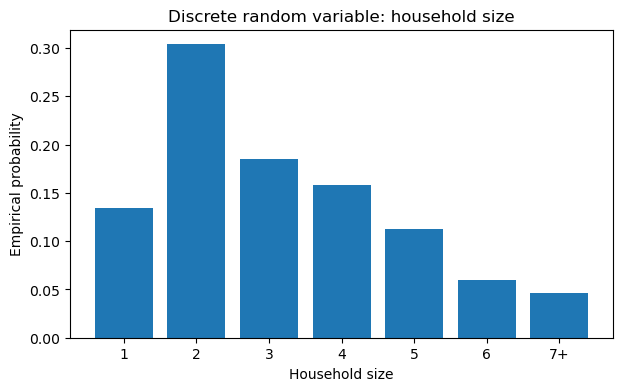

In [5]:
labels = [str(x) if x < 7 else "7+" for x in pmf["household_size_code"]]

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(labels, pmf["empirical_probability"])
ax.set_xlabel("Household size")
ax.set_ylabel("Empirical probability")
ax.set_title("Discrete random variable: household size")
plt.show()

## TEST FOR YOURSELF: What is the CDF for the above distribution ?


For a discrete variable we can estimate a probability mass function by

$$
\widehat P(X=x)
=
\frac{\#\{i:X_i=x\}}{N}.
$$

For example, the empirical probability that the released household-size code equals \(4\) is:


In [22]:
p_hh4 = (hh == 4).mean()
print(f"Empirical P(X = 4) = {p_hh4:.3f}")

Empirical P(X = 4) = 0.158



## 3. From a discrete variable to a Bernoulli variable

A Bernoulli random variable can be constructed by asking a yes/no question about an outcome.

Define

$$
B(\omega)
=
\mathbf 1\{X(\omega)\ge 4\}.
$$

Then

$$
B\in\{0,1\}.
$$

This is a Bernoulli random variable.


In [17]:
B = (hh >= 4).astype(int)  # B is just a indicator random variable we discussed in the class
print(B.shape)
p_hat = B.mean()

print("Observed values:", sorted(B.unique()))
print(f"Sample proportion with household-size code >= 4: {p_hat:.3f}")
print(f"Mean of the indicator variable:                 {B.mean():.3f}")
print(f"Bernoulli variance p_hat(1-p_hat):              {p_hat*(1-p_hat):.3f}")

(5434,)
Observed values: [0, 1]
Sample proportion with household-size code >= 4: 0.377
Mean of the indicator variable:                 0.377
Bernoulli variance p_hat(1-p_hat):              0.235



Because $B_i\in\{0,1\}$

$$
\bar B
=
\frac{1}{N}\sum_{i=1}^N B_i
=
\frac{\#\{i:B_i=1\}}{N}.
$$

Therefore

$$
\boxed{\text{a sample proportion is a sample mean of indicator random variables}.}
$$



# Part III - Continuous random variables

## 4. Standing height

Let

$$
Y(\omega)=\text{standing height of participant }\omega.
$$

Height is naturally modeled as a continuous random variable, even though a measuring
instrument records it to finite precision.


In [18]:
height = adults["height_cm"]
print(height.describe())

count    5434.000000
mean      166.358852
std        10.062678
min       138.300000
25%       158.900000
50%       165.900000
75%       173.600000
max       197.700000
Name: height_cm, dtype: float64


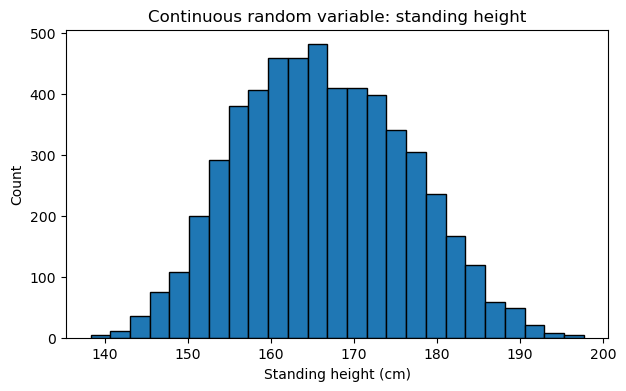

In [19]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(height, bins=25, edgecolor="black")
ax.set_xlabel("Standing height (cm)")
ax.set_ylabel("Count")
ax.set_title("Continuous random variable: standing height")
plt.show()


For a continuous model, the probability of an interval is

$$
P(a<Y<b)
=
\int_a^b f_Y(y)\,dy.
$$

The sample analogue is simply the fraction of observations lying inside the interval.


In [20]:
a, b = 165, 175
p_interval = ((height > a) & (height < b)).mean()
print(f"Empirical fraction with {a} < height < {b} cm: {p_interval:.3f}")

Empirical fraction with 165 < height < 175 cm: 0.313



## 5. BMI: another continuous variable

The CDC body-measures documentation states that BMI is calculated as

$$
\mathrm{BMI}
=
\frac{\text{weight in kg}}{(\text{height in m})^2}
$$

and released rounded to one decimal place.

The underlying quantity is modeled continuously; the finite decimal precision is a
measurement/data-storage feature.


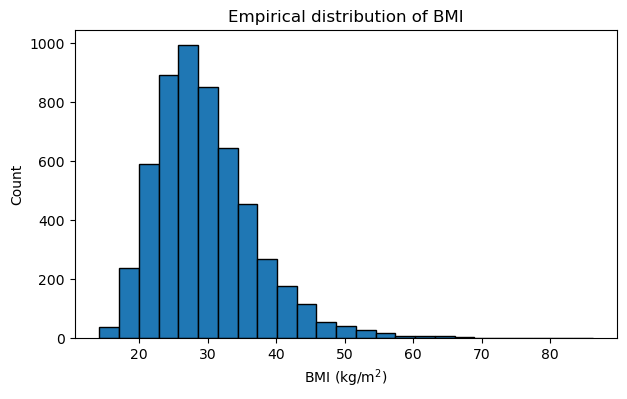

In [21]:
bmi = adults["bmi"]
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(bmi, bins=25, edgecolor="black")
ax.set_xlabel(r"BMI (kg/m$^2$)")
ax.set_ylabel("Count")
ax.set_title("Empirical distribution of BMI")
plt.show()

# Part IV - Data science connection: empirical distributions

A dataset gives us an **empirical distribution**. It is an estimate about the actual underlying distribution.

For a discrete variable:

$$
\widehat P(X=x)
=
\frac{1}{N}\sum_{i=1}^N \mathbf 1\{X_i=x\}.
$$

For an interval of a continuous variable:

$$
\widehat P(a<Y<b)
=
\frac{1}{N}\sum_{i=1}^N \mathbf 1\{a<Y_i<b\}.
$$

Both are averages of indicator random variables.


# Part V - Sample size and fluctuations

Treat the observed Bernoulli proportion $p=\bar B$ as a temporary population model.

For a sample of size $N$,

$$
\hat p=\frac{1}{N}\sum_{i=1}^N B_i,
$$

and for independent Bernoulli observations,

$$
E[\hat p]=p,
\qquad
\operatorname{Var}(\hat p)=\frac{p(1-p)}{N}.
$$

Hence

$$
\boxed{
\operatorname{SD}(\hat p)
=
\sqrt{\frac{p(1-p)}{N}}
\propto \frac{1}{\sqrt N}.
}
$$


In [33]:
p = p_hat
sample_sizes = [20, 50, 100, 500, 2000]
R = 5000

results = []

for N in sample_sizes:
    simulated_phat = rng.binomial(N, p, size=R) / N

    results.append({
        "N": N,
        "mean_of_simulated_phat": simulated_phat.mean(),
        "sd_of_simulated_phat": simulated_phat.std(ddof=0),
        "theoretical_sd": np.sqrt(p * (1 - p) / N),
    })

pd.DataFrame(results)

,N,mean_of_simulated_phat,sd_of_simulated_phat,theoretical_sd
0,20,0.376690,0.108886,0.108351
1,50,0.376992,0.069582,0.068527
2,100,0.377336,0.047688,0.048456
3,500,0.376253,0.021838,0.021670
4,2000,0.376741,0.010998,0.010835


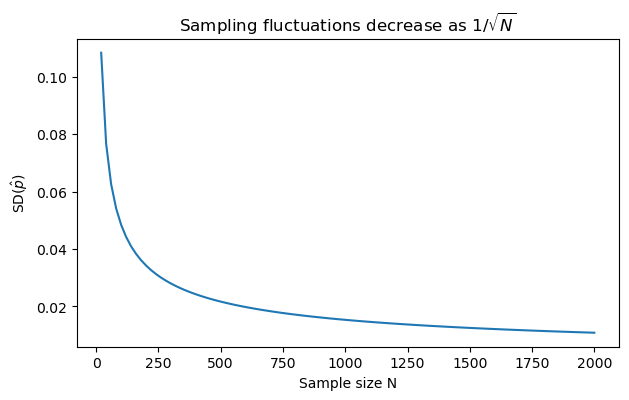

In [35]:
Ns = np.arange(20, 2001, 20)
theory = np.sqrt(p * (1 - p) / Ns)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(Ns, theory)
ax.set_xlabel("Sample size N")
ax.set_ylabel(r"SD($\hat p$)")
ax.set_title(r"Sampling fluctuations decrease as $1/\sqrt{N}$")
plt.show()


# Part VI - Preview of the Law of Large Numbers

Now treat the observed heights as an empirical population.

If we repeatedly draw observations and compute

$$
\bar Y_N=\frac{1}{N}\sum_{i=1}^N Y_i,
$$

the sample average becomes increasingly stable as \(N\) grows.


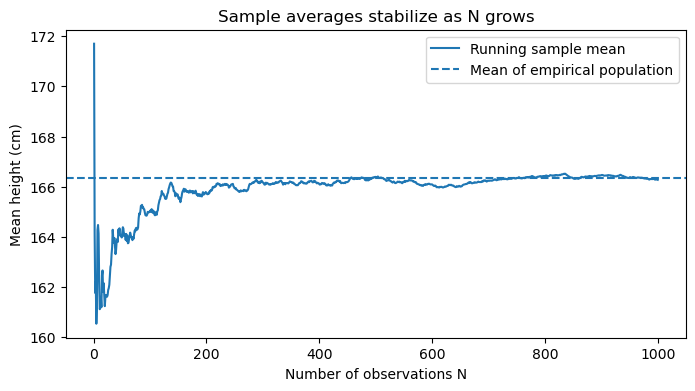

In [32]:
population = height.to_numpy()
mu_empirical = population.mean()

N_max = 1000
draws = rng.choice(population, size=N_max, replace=True)
running_mean = np.cumsum(draws) / np.arange(1, N_max + 1)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(np.arange(1, N_max + 1), running_mean, label="Running sample mean")
ax.axhline(mu_empirical, linestyle="--", label="Mean of empirical population")
ax.set_xlabel("Number of observations N")
ax.set_ylabel("Mean height (cm)")
ax.set_title("Sample averages stabilize as N grows")
ax.legend()
plt.show()



This motivates the Law of Large Numbers:

$$
\boxed{\bar Y_N\longrightarrow \mu.}
$$

The next question is subtler:

> **What is the distribution of the remaining fluctuations around \(\mu\)?**

That question leads to the **Central Limit Theorem**.



# Discussion questions

1. What is the random experiment?
2. What is an outcome $\omega$?
3. Why can the same participant record generate both discrete and continuous random variables?
4. Why is household size discrete?
5. Why is height modeled as continuous even though the instrument records finite decimals?
6. Why is
$$
   \frac1N\sum_i \mathbf 1\{X_i\in A\}
$$
   an empirical probability?
7. Why is a sample proportion a sample mean?
8. What does increasing $N$ change?
9. What additional machinery would we need before treating the unweighted NHANES sample as representative of the U.S. population?



# Take-home message

Real datasets provide observations of random variables:

$$
\boxed{
\text{outcome}
\longrightarrow
\text{random variable}
\longrightarrow
\text{empirical distribution}
}
$$

and repeated observations lead naturally to

$$
\boxed{
\text{sample average}
\longrightarrow
\text{sampling fluctuations}
\longrightarrow
\text{LLN / CLT}.
}
$$

**Data source:** CDC/NCHS, National Health and Nutrition Examination Survey,
2017–2018 public-use files `DEMO_J` and `BMX_J`.
